# Reconstruction diagnostics: graft ScenarioMIP products vs LUH3

This notebook assesses the seven graft ScenarioMIP land-use products (annual,
2020-2100, `gross,fold`) against the published LUH3 scenarios **where they
exist**. Only two markers have a direct LUH3 counterpart:

| marker | scenario | LUH3 reference |
|---|---|---|
| **vl** | Very Low - SSP1 | `UofMD-landState-vl-3-1` |
| **h**  | High - SSP3     | `UofMD-landState-h-3-1`  |
| l, ln, m, ml, hl | (SSP2/SSP5 variants) | none published |

For the five markers without a LUH3 scenario we still show global and
large-scale trajectories, and every marker is checked against LUH3 **history**
at the 2024/2025 splice.

**Convention.** LUH3 folds plantations into `secdf` (its `pltns` is NaN in the
scenarios); the graft products now do the same (`foldPlantations`). So `secdf`
is directly comparable and "forest" = `primf + secdf` on both sides. Areas are
cell fraction x cell area (`carea`, km2) / 1e4 = Mha.

**Runs.** All seven markers are the phase-1 set (`<tag>p1`): gross
transitions, plantation fold, LUH3's harvest semantics, primary forest driven
by the scenario's wood demand, and urban land put on LUH's level (fork branch
`graft/primary-forest-harvest`). LUH3 is a benchmark here, not a target.


In [1]:
%matplotlib inline
import os, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
from graft import compare            # scoring toolkit (folding, group areas, skill)
from graft.io import luh             # readers

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


In [2]:
# ---- configuration -------------------------------------------------------
from graft import paths      # LUH3 locations, set by GRAFT_LUH3_SCENARIOS
OUT   = os.path.expanduser("~/madrat/output")            # graft products
LUH2  = str(paths.LUH3_SCENARIOS)                    
STATIC = f"{LUH2}/UofMD-landState-3-1-1/multiple-static_input4MIPs_landState_CMIP_UofMD-landState-3-1-1_gn.nc"
HIST_STATES = glob.glob(f"{LUH2}/UofMD-landState-3-1-1/multiple-states_*.nc")[0]

# marker tag -> (label, LUH3 scenario dir or None)
MARKERS = {
    "vl": ("Very Low (SSP1)",        f"{LUH2}/UofMD-landState-vl-3-1"),
    "l":  ("Low (SSP2)",             None),
    "ln": ("Low-to-Negative (SSP2)", None),
    "m":  ("Medium (SSP2)",          None),
    "ml": ("Medium-to-Low (SSP2)",   None),
    "h":  ("High (SSP3)",            f"{LUH2}/UofMD-landState-h-3-1"),
    "hl": ("High-to-Low (SSP5)",     None),
}
ORDER = list(MARKERS)
# official ScenarioMIP marker colours; LUH3 is told apart by line style (dashed)
COLOR = {"h": "#a41212", "hl": "#E744F6", "m": "#fc7b03", "ml": "#dec820",
         "l": "#20A359", "ln": "#22e5db", "vl": "#16188F"}
LUH_STYLE = (0, (4, 2))

STATES = ["primf", "secdf", "secdn", "primn", "c3ann", "c4ann", "c3per",
          "c4per", "c3nfx", "pastr", "range", "urban"]
CROP = ["c3ann", "c4ann", "c3per", "c4per", "c3nfx"]

def find(pat):
    f = glob.glob(pat)
    if not f:
        raise FileNotFoundError(pat)
    return f[0]

# which run each marker is read from: gross transitions, plantation fold,
# LUH3 harvest semantics (primary harvest per cell), primary forest from wood
# demand, urban crosswalk, harvest target at the last historical density,
# energy crops to dedicated bioenergy, category weights from LUH3 2024,
# planted forest from consistent years -
# fork branch graft/primary-forest-harvest. The x7 runs carry on to 2150 on
# the extension ramp; this notebook reads their scenario period, to 2100.
RUN = {t: f"{t}x7" for t in ["vl", "l", "ln", "m", "ml", "h", "hl"]}
YEAR_MAX = 2100

def marker_file(tag, kind, annual=True):
    sub = "annual/" if annual else ""
    return find(f"{OUT}/{RUN.get(tag, tag)}_iamc/{sub}multiple-{kind}_*.nc")

def luh_file(scen_dir, kind):
    return find(f"{scen_dir}/multiple-{kind}_*.nc")

def years_of(ds):
    """Integer calendar years from a 'days since Y-..' (or 'years since') axis."""
    t = np.asarray(ds["time"].values, dtype="float64")
    units = str(ds["time"].attrs.get("units", "days since 1970-1-1"))
    epoch = int(units.split("since")[-1].strip().split("-")[0])
    if units.strip().startswith("days"):
        return np.array([int(round(epoch + v / 365.0)) for v in t])
    return np.array([int(round(epoch + v)) for v in t])

# cell area as a (lat, lon) DataArray on the common grid
_static = luh.open_static(STATIC)
CAREA = _static["carea"]                       # km2
carea_np = np.asarray(CAREA.values, dtype="float64")
print("grid", dict(CAREA.sizes), "| total land+ocean area (Mha)",
      f"{float(CAREA.sum())/1e4:,.0f}")


grid {'lat': 720, 'lon': 1440} | total land+ocean area (Mha) 51,006


## 1. Global state trajectories (all seven markers)

Global area (Mha) of each land state over 2020-2100. LUH3-VL and LUH3-h are
overlaid (dashed, black/grey) on the panels for states they report.

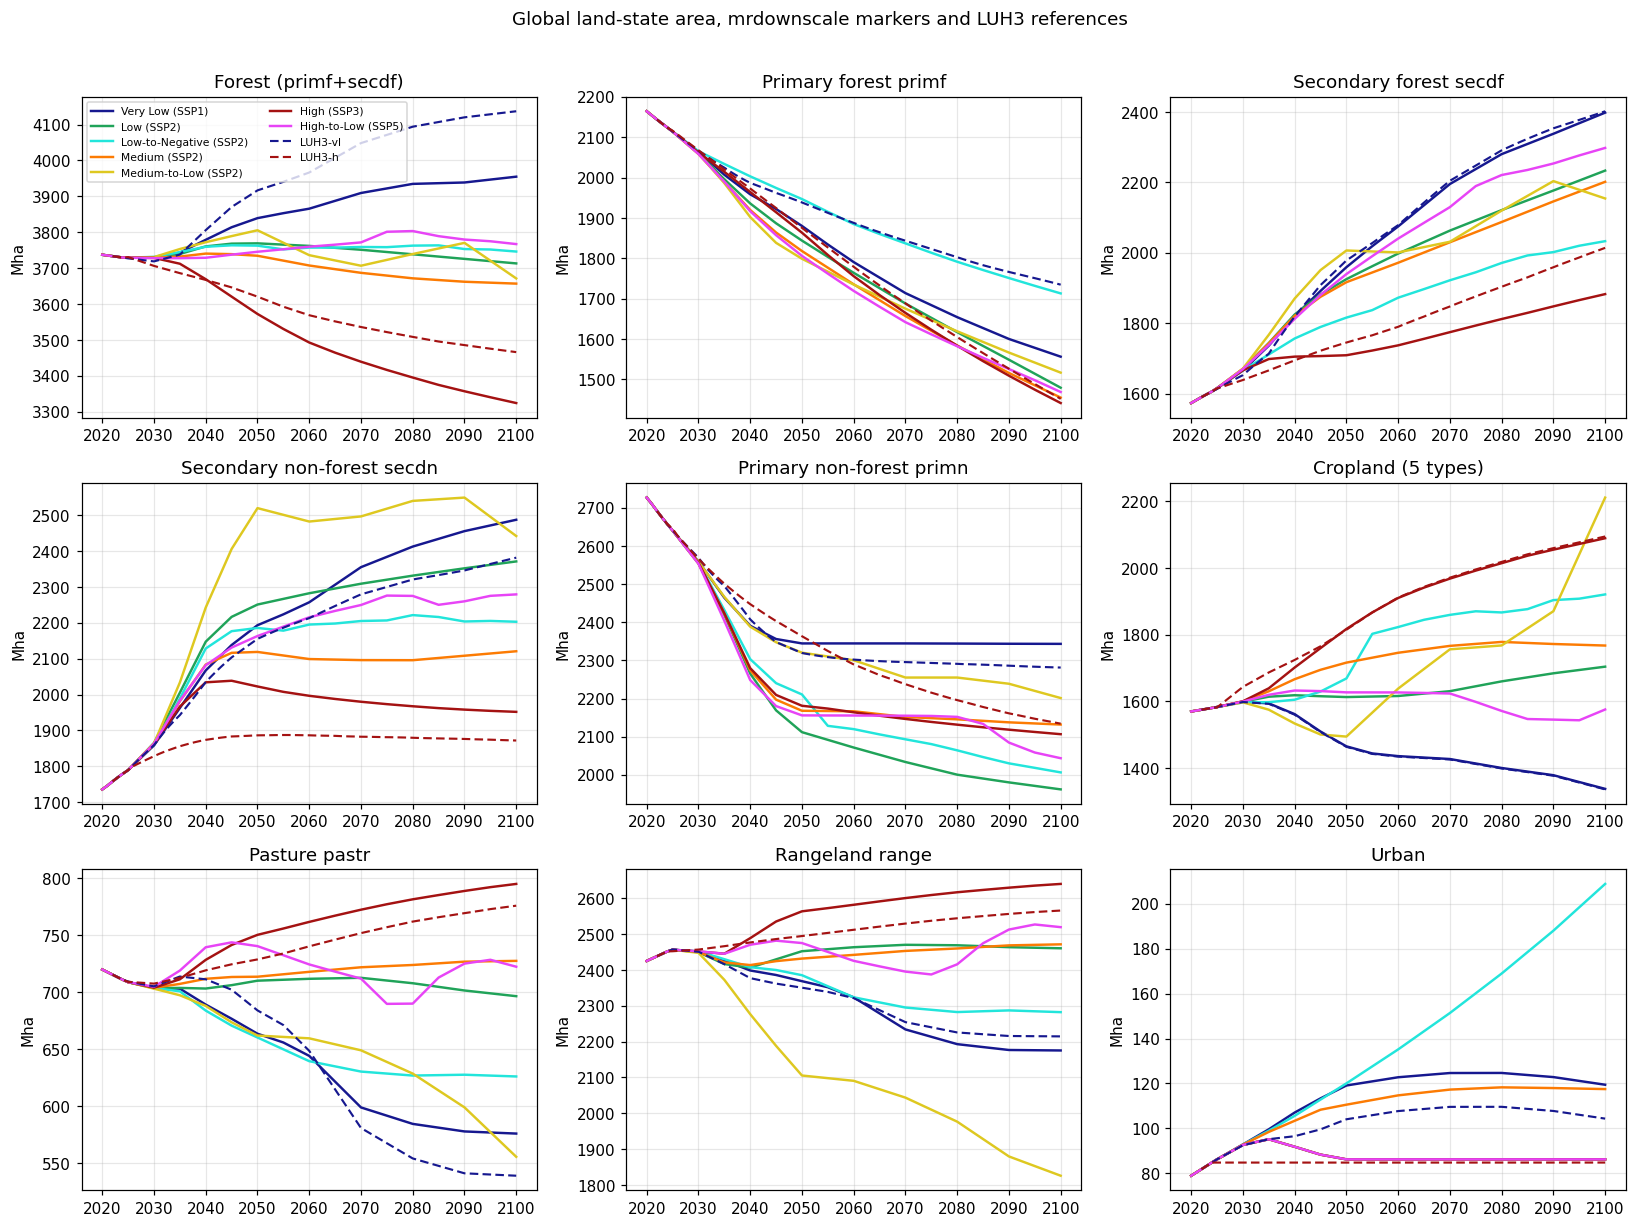

In [3]:
def global_series(states, years):
    """DataFrame [year x state] of global area in Mha (fraction * carea)."""
    rows = {}
    for v in states.data_vars:
        if states[v].dims[-2:] != ("lat", "lon"):
            continue
        rows[v] = (states[v] * CAREA).sum(("lat", "lon"), skipna=True).values / 1e4
    df = pd.DataFrame(rows, index=years)
    df.index.name = "year"
    return df

# our seven products
G = {}
for tag in ORDER:
    ds = xr.open_dataset(marker_file(tag, "states"), decode_times=False)
    G[tag] = global_series(ds, years_of(ds)).loc[:YEAR_MAX]
    ds.close()

# LUH3 references
GL = {}
for key in ("vl", "h"):
    ds = xr.open_dataset(luh_file(MARKERS[key][1], "states"), decode_times=False)
    GL[key] = global_series(ds, years_of(ds))
    ds.close()

def agg(df, cols):
    return df[[c for c in cols if c in df]].sum(axis=1)

PANELS = [("Forest (primf+secdf)", ["primf", "secdf"]),
          ("Primary forest primf", ["primf"]),
          ("Secondary forest secdf", ["secdf"]),
          ("Secondary non-forest secdn", ["secdn"]),
          ("Primary non-forest primn", ["primn"]),
          ("Cropland (5 types)", CROP),
          ("Pasture pastr", ["pastr"]),
          ("Rangeland range", ["range"]),
          ("Urban", ["urban"])]

fig, axes = plt.subplots(3, 3, figsize=(15, 11)); axes = axes.ravel()
for ax, (title, cols) in zip(axes, PANELS):
    for tag in ORDER:
        ax.plot(G[tag].index, agg(G[tag], cols), color=COLOR[tag],
                lw=1.6, label=MARKERS[tag][0])
    for key, style in (("vl", (0, (4, 2))), ("h", (0, (1, 1)))):
        ax.plot(GL[key].index, agg(GL[key], cols), color=COLOR[key], lw=1.4,
                ls=LUH_STYLE, label=f"LUH3-{key}")
    ax.set_title(title); ax.set_ylabel("Mha")
axes[0].legend(fontsize=7, ncol=2, loc="best")
fig.suptitle("Global land-state area, mrdownscale markers and LUH3 references", y=1.01)
fig.tight_layout(); plt.show()


## 2. Direct comparison against LUH3 (vl and h)

For the two markers with a published LUH3 scenario: time series of each major
group (ours solid, LUH3 dashed) over the overlap, and the difference
(ours - LUH3).

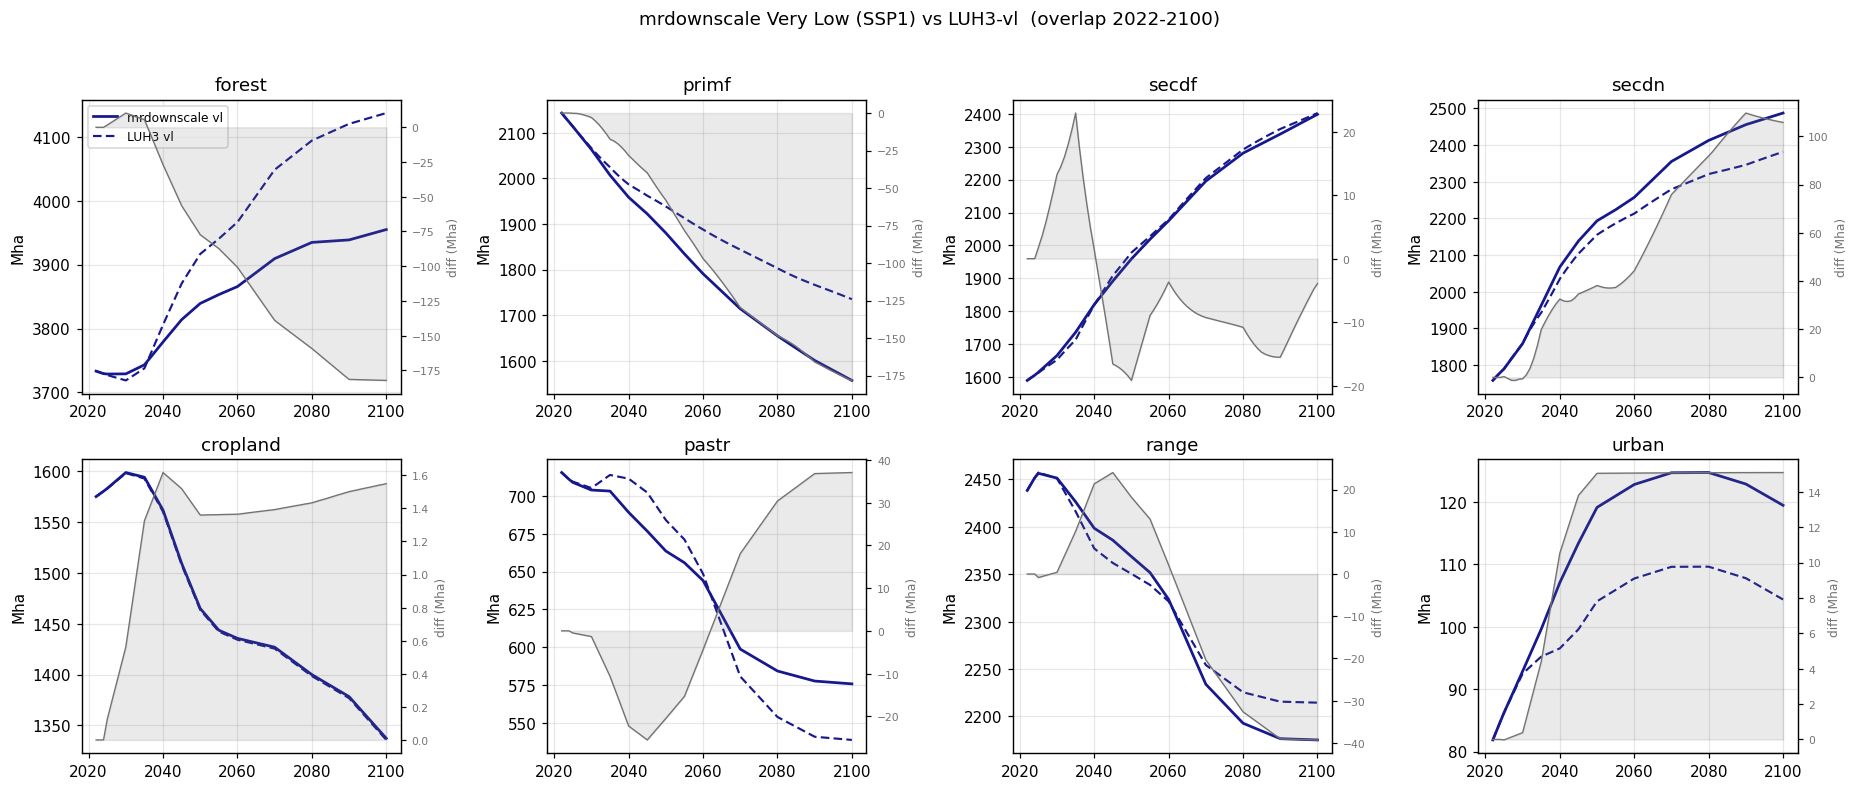

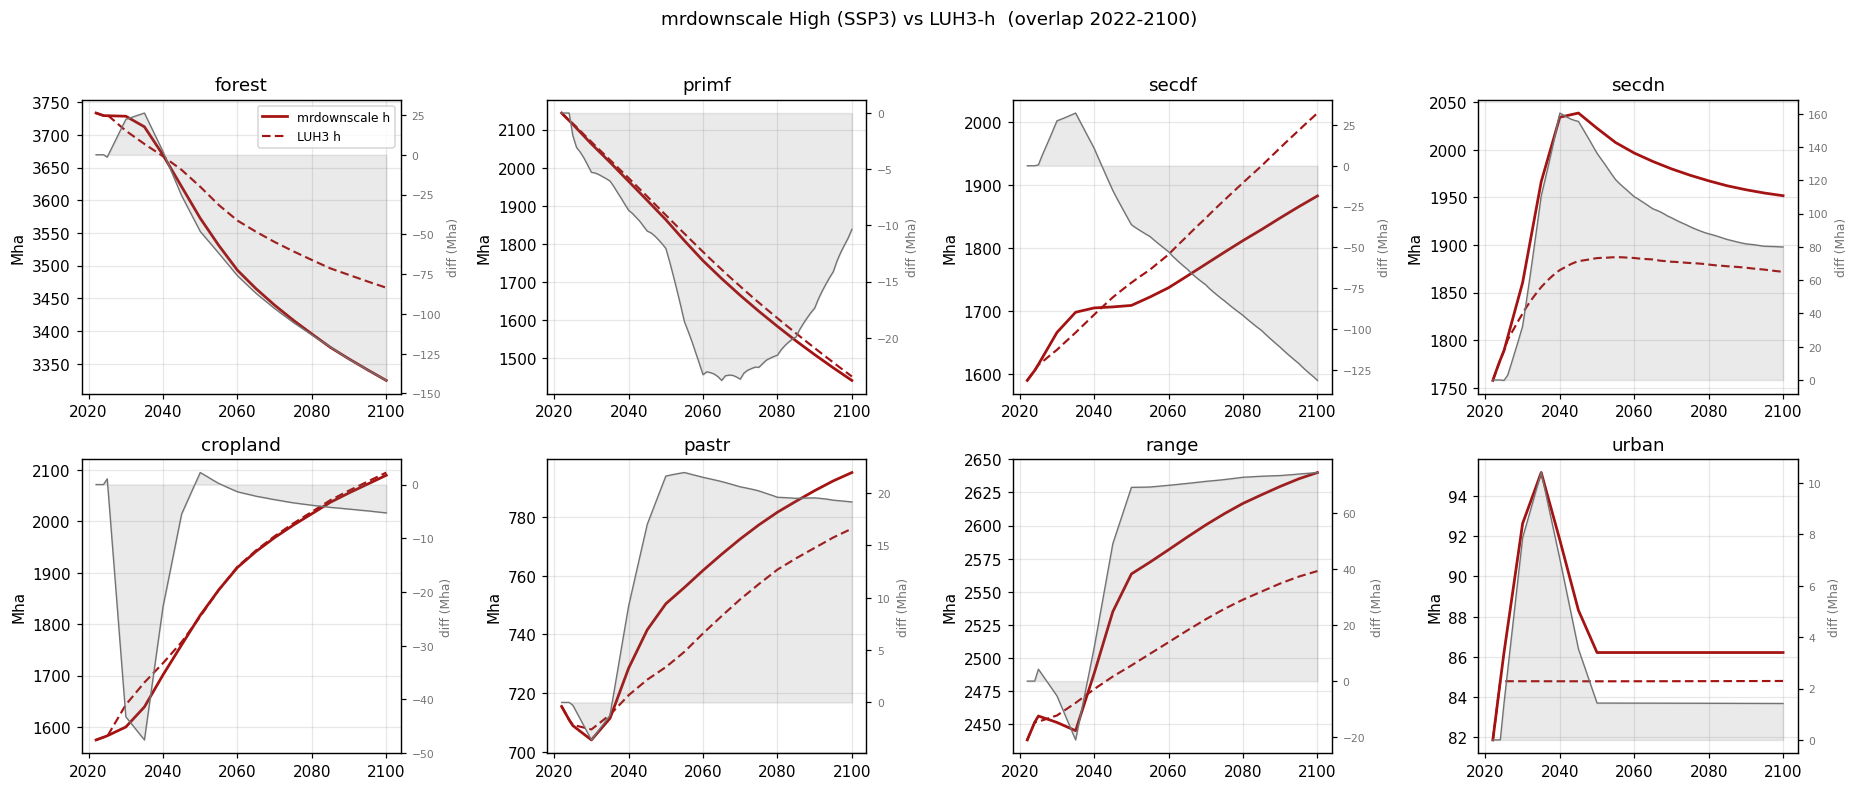

In [4]:
GROUPS = {"forest": ["primf", "secdf"], "primf": ["primf"], "secdf": ["secdf"],
          "secdn": ["secdn"], "cropland": CROP, "pastr": ["pastr"],
          "range": ["range"], "urban": ["urban"]}

for key in ("vl", "h"):
    ours, ref = G[key], GL[key]
    yrs = sorted(set(ours.index) & set(ref.index))
    fig, axes = plt.subplots(2, 4, figsize=(17, 7)); axes = axes.ravel()
    for ax, (name, cols) in zip(axes, GROUPS.items()):
        o = agg(ours, cols).reindex(yrs); r = agg(ref, cols).reindex(yrs)
        ax.plot(yrs, o, color=COLOR[key], lw=1.8, label=f"mrdownscale {key}")
        ax.plot(yrs, r, color=COLOR[key], lw=1.4, ls=LUH_STYLE, label=f"LUH3 {key}")
        ax2 = ax.twinx()
        ax2.fill_between(yrs, (o - r), 0, color="0.45", alpha=0.15)
        ax2.plot(yrs, (o - r), color="0.45", lw=0.9)
        ax2.set_ylabel("diff (Mha)", color="0.45", fontsize=8)
        ax2.tick_params(axis="y", labelcolor="0.45", labelsize=7)
        ax2.grid(False)
        ax.set_title(f"{name}"); ax.set_ylabel("Mha")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"mrdownscale {MARKERS[key][0]} vs LUH3-{key}  "
                 f"(overlap {yrs[0]}-{yrs[-1]})", y=1.02)
    fig.tight_layout(); plt.show()


### 2b. Cell-level skill (vl and h)

`compare.score_cells` at 2050 and 2100: global totals, gap, per-cell mean
absolute error and correlation, over the reference's land mask. Plantations are
folded into `secdf` on both sides.

In [5]:
def states_at(path, year, decode_epoch=None):
    ds = xr.open_dataset(path, decode_times=False)
    yrs = years_of(ds)
    k = int(np.argmin(np.abs(yrs - year)))
    return ds.isel(time=k), int(yrs[k])

for key in ("vl", "h"):
    for year in (2050, 2100):
        o, yo = states_at(marker_file(key, "states"), year)
        r, yr = states_at(luh_file(MARKERS[key][1], "states"), year)
        tbl = compare.score_cells(o, r, carea_np)
        print(f"\n=== {key}: graft({yo}) vs LUH3({yr}) ===")
        display(tbl)
        o.close(); r.close()



=== vl: graft(2050) vs LUH3(2050) ===


,ours (Mha),reference (Mha),gap (Mha),gap (%),cell MAE (kha),cell corr
group,,,,,,
forest,"3,839.24","3,916.58",-77.34,-1.97,1.39,0.98
primf,"1,880.18","1,938.35",-58.16,-3.00,0.74,0.99
secdf,"1,959.06","1,978.23",-19.17,-0.97,1.68,0.95
primn,"2,344.48","2,319.35",25.13,1.08,1.13,0.98
secdn,"2,193.23","2,155.12",38.10,1.77,2.23,0.95
crop,"1,464.82","1,463.46",1.36,0.09,2.01,0.89
pastr,663.56,684.05,-20.49,-2.99,0.74,0.95
range,"2,368.61","2,350.43",18.18,0.77,1.56,0.98
urban,119.11,104.06,15.05,14.46,0.11,0.99



=== vl: graft(2100) vs LUH3(2100) ===


,ours (Mha),reference (Mha),gap (Mha),gap (%),cell MAE (kha),cell corr
group,,,,,,
forest,"3,954.72","4,136.93",-182.21,-4.40,1.94,0.98
primf,"1,556.51","1,734.79",-178.28,-10.28,1.79,0.96
secdf,"2,398.22","2,402.14",-3.93,-0.16,2.93,0.92
primn,"2,343.32","2,281.23",62.08,2.72,1.26,0.96
secdn,"2,487.22","2,381.48",105.74,4.44,2.87,0.93
crop,"1,337.28","1,335.73",1.55,0.12,2.30,0.86
pastr,575.82,538.78,37.04,6.87,0.95,0.89
range,"2,175.26","2,214.55",-39.29,-1.77,2.03,0.96
urban,119.44,104.35,15.09,14.46,0.14,0.99



=== h: graft(2050) vs LUH3(2050) ===


,ours (Mha),reference (Mha),gap (Mha),gap (%),cell MAE (kha),cell corr
group,,,,,,
forest,"3,572.39","3,620.57",-48.18,-1.33,0.82,0.99
primf,"1,863.51","1,875.56",-12.06,-0.64,0.90,0.99
secdf,"1,708.88","1,745.00",-36.12,-2.07,1.12,0.98
primn,"2,181.02","2,363.36",-182.35,-7.72,1.96,0.92
secdn,"2,022.42","1,886.17",136.25,7.22,2.15,0.94
crop,"1,817.03","1,814.80",2.24,0.12,1.69,0.98
pastr,750.46,728.87,21.60,2.96,0.55,0.98
range,"2,563.53","2,494.52",69.01,2.77,1.08,0.99
urban,86.21,84.78,1.43,1.69,0.06,1.00



=== h: graft(2100) vs LUH3(2100) ===


,ours (Mha),reference (Mha),gap (Mha),gap (%),cell MAE (kha),cell corr
group,,,,,,
forest,"3,324.27","3,466.10",-141.83,-4.09,1.45,0.98
primf,"1,441.69","1,452.05",-10.36,-0.71,1.87,0.95
secdf,"1,882.58","2,014.05",-131.47,-6.53,2.03,0.94
primn,"2,106.48","2,134.09",-27.62,-1.29,2.44,0.88
secdn,"1,951.64","1,871.74",79.90,4.27,3.00,0.90
crop,"2,089.28","2,094.55",-5.27,-0.25,2.96,0.94
pastr,795.21,776.09,19.13,2.46,1.03,0.93
range,"2,639.97","2,565.69",74.28,2.90,1.86,0.98
urban,86.21,84.79,1.42,1.67,0.06,1.00


### 2c. Skill vs spatial scale (forest, 2100)

`compare.score_by_resolution`: a field can be right at 5 degrees and wrong at
0.25. Correlation and relative absolute error of forest area as cells
are aggregated into k x k blocks (k=1 is native 0.25 deg, 4 is 1 deg, 20 is 5).

In [6]:
for key in ("vl", "h"):
    o, yo = states_at(marker_file(key, "states"), 2100)
    r, yr = states_at(luh_file(MARKERS[key][1], "states"), 2100)
    land = compare.land_cells(r)
    of = compare.group_areas(o, carea_np, {"forest": ("primf", "secdf")})["forest"]
    rf = compare.group_areas(r, carea_np, {"forest": ("primf", "secdf")})["forest"]
    print(f"\n=== {key}: forest skill vs resolution ({yo}) ===")
    display(compare.score_by_resolution(of, rf, land))
    o.close(); r.close()



=== vl: forest skill vs resolution (2100) ===


,corr,relative absolute error
factor,,
1,0.98,0.12
4,0.98,0.12
8,0.98,0.11
20,0.99,0.10



=== h: forest skill vs resolution (2100) ===


,corr,relative absolute error
factor,,
1,0.98,0.11
4,0.99,0.10
8,0.99,0.10
20,0.99,0.08


## 3. The splice into LUH3 history (all markers)

An ESM runs LUH3 history then a scenario, so the 2024->2025 join must be
seamless. Before the plantation fold this broke by ~223 Mha (secdf low, pltns
high). Here: each marker's states at 2025 vs LUH3 **history** at its
last year (2024), forest and its parts.

In [7]:
hist = xr.open_dataset(HIST_STATES, decode_times=False)
hyr = years_of(hist)
hk = int(np.argmin(np.abs(hyr - 2024)))
hist24 = hist.isel(time=hk)
h_area = {g: float((sum(np.nan_to_num(hist24[c].values) for c in cols) * carea_np).sum()) / 1e4
          for g, cols in {"forest": ["primf", "secdf"], "primf": ["primf"],
                          "secdf": ["secdf"]}.items()}
rows = []
for tag in ORDER:
    o, yo = states_at(marker_file(tag, "states"), 2025)
    ga = compare.group_areas(o, carea_np, {"forest": ("primf", "secdf"),
                                           "primf": ("primf",), "secdf": ("secdf",)})
    rows.append({"marker": tag, "year": yo,
                 "forest ours": ga["forest"].sum(), "forest LUH3hist": h_area["forest"],
                 "forest gap": ga["forest"].sum() - h_area["forest"],
                 "secdf gap": ga["secdf"].sum() - h_area["secdf"],
                 "primf gap": ga["primf"].sum() - h_area["primf"]})
    o.close()
hist.close()
splice = pd.DataFrame(rows).set_index("marker")
print("gaps are ours(2025) - LUH3 history(2024), Mha")
display(splice)


gaps are ours(2025) - LUH3 history(2024), Mha


,year,forest ours,forest LUH3hist,forest gap,secdf gap,primf gap
marker,,,,,,
vl,2025,"3,728.83","3,729.46",-0.63,9.19,-9.82
l,2025,"3,729.15","3,729.46",-0.31,9.52,-9.82
ln,2025,"3,729.27","3,729.46",-0.19,9.64,-9.82
m,2025,"3,729.15","3,729.46",-0.31,9.51,-9.82
ml,2025,"3,729.27","3,729.46",-0.19,9.63,-9.82
h,2025,"3,729.23","3,729.46",-0.23,9.59,-9.82
hl,2025,"3,729.10","3,729.46",-0.36,9.46,-9.82


## 3b. Plausibility (all seven markers)

Checks that need no reference, so they apply to the five markers LUH3 does
not publish as well: urban land never falls below its 2025 level for want of
reporting; primary land never expands, globally or in any cell; no category is
emptied; and primary forest loss now differs between scenarios. Closure of
states and transitions under LUH3's rule is checked separately
(`annualise.check`, every 5th year), since it reads every transition field.

In [8]:
rows = []
for tag in ORDER:
    g = G[tag][G[tag].index >= 2025]   # the scenario period; history before 2025 is LUH3's own
    urban_drop = float((g["urban"] - g.loc[2025, "urban"]).min())
    prim_rise = {v: float(g[v].diff().max()) for v in ("primf", "primn")}
    exhausted = [v for v in g.columns if g.loc[2025, v] > 10 and g[v].min() < 0.05 * g.loc[2025, v]]
    rows.append({"marker": tag, "urban 2025": g.loc[2025, "urban"], "urban 2100": g.loc[2100, "urban"],
                 "urban lowest vs 2025": urban_drop,
                 "primf max annual rise": prim_rise["primf"], "primn max annual rise": prim_rise["primn"],
                 "primf loss 2025-2100, Mha/yr": (g.loc[2025, "primf"] - g.loc[2100, "primf"]) / 75,
                 "categories below 5% of 2025": ", ".join(exhausted) or "none"})
plaus = pd.DataFrame(rows).set_index("marker")
display(plaus)

# primary land expanding in any cell, 2025 -> 2100
cells = []
for tag in ORDER:
    a, _ = states_at(marker_file(tag, "states"), 2025)
    b, _ = states_at(marker_file(tag, "states"), 2100)
    for v in ("primf", "primn"):
        d = (np.nan_to_num(b[v].values) - np.nan_to_num(a[v].values)) * carea_np / 1e4
        cells.append({"marker": tag, "state": v, "cells expanding > 1 ha": int((d > 1e-4).sum()),
                      "area gained, Mha": float(d[d > 0].sum())})
    a.close(); b.close()
display(pd.DataFrame(cells).pivot(index="marker", columns="state"))

ok = (plaus["urban lowest vs 2025"] > -1).all() and (plaus[["primf max annual rise", "primn max annual rise"]] < 0.01).all().all()
print("global plausibility:", "PASS" if ok else "CHECK")
print("primary forest loss spread across markers:",
      f"{plaus['primf loss 2025-2100, Mha/yr'].min():.2f}-{plaus['primf loss 2025-2100, Mha/yr'].max():.2f} Mha/yr")

,urban 2025,urban 2100,urban lowest vs 2025,primf max annual rise,primn max annual rise,"primf loss 2025-2100, Mha/yr",categories below 5% of 2025
marker,,,,,,,
vl,86.21,119.44,0.00,-4.39,0.00,7.43,none
l,86.21,86.21,0.00,-6.84,-1.83,8.46,none
ln,86.21,208.88,0.00,-3.74,-1.72,5.34,none
m,86.21,117.51,0.00,-6.09,-0.14,8.78,none
ml,86.21,86.21,-0.00,-4.97,0.00,7.96,none
h,86.21,86.21,-0.00,-6.63,-1.17,8.96,none
hl,86.21,86.21,-0.00,-5.54,-0.03,8.60,none


cells expanding > 1 ha       area gained, Mha      
state                   primf primn            primf primn
marker                                                    
h                           0     0             0.00  0.00
hl                          0     0             0.00  0.00
l                           0     0             0.00  0.00
ln                          0     0             0.00  0.00
m                           0     0             0.00  0.00
ml                          0     0             0.00  0.00
vl                          0     0             0.00  0.00

global plausibility: PASS
primary forest loss spread across markers: 5.34-8.96 Mha/yr


## 4. Wood harvest (vl and h vs LUH3)

Global biomass harvest (`*_bioh`, Pg C/yr) and area harvested (`*_harv`, share
of carea -> Mha/yr). LUH3 splits secondary harvest into `secmf`+`secyf`; graft
writes one `secdf`, so those are summed on the LUH3 side and
`secdf`+`pltns` on ours.

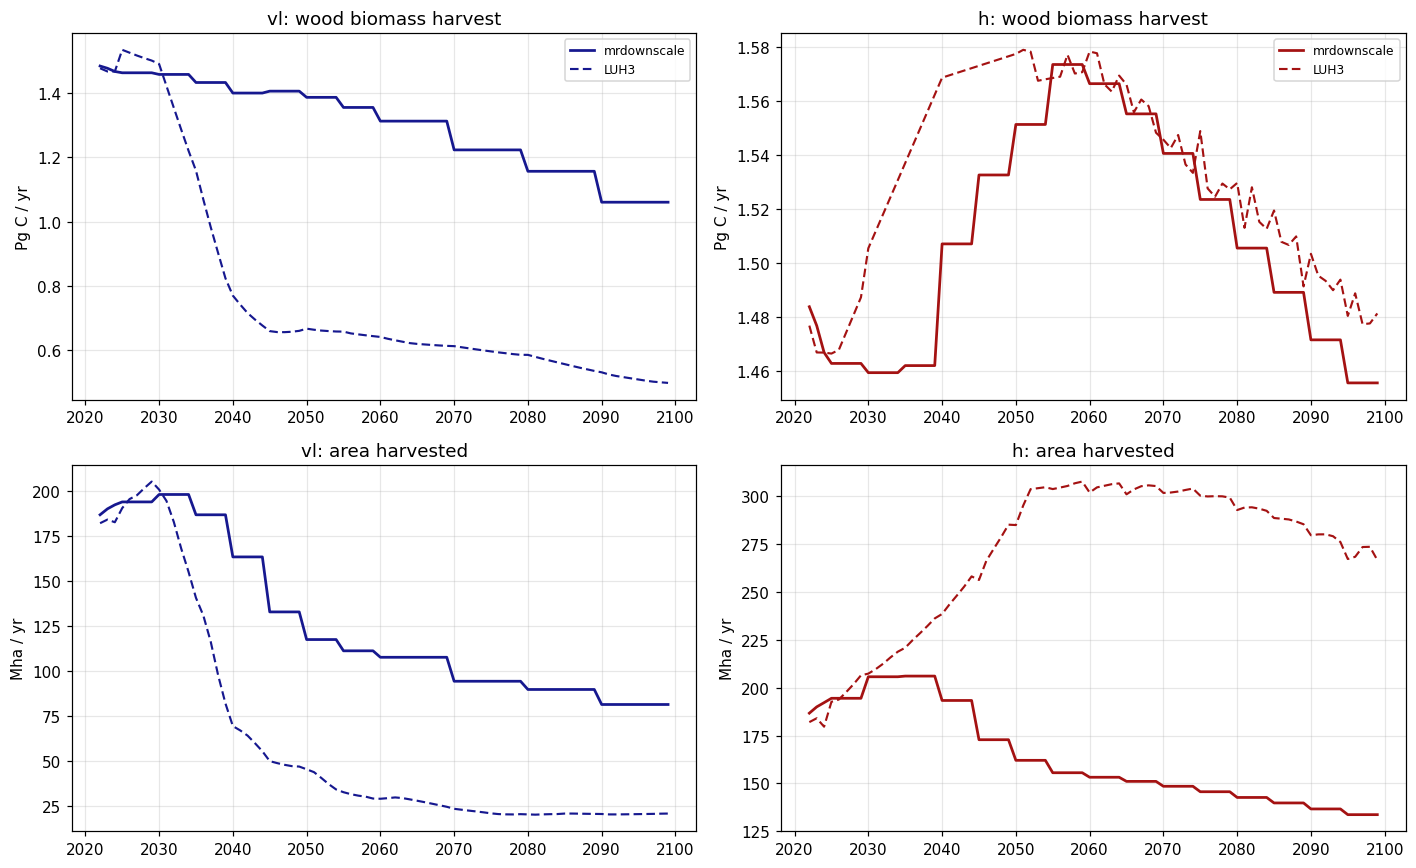

In [9]:
def harvest_series(path):
    ds = xr.open_dataset(path, decode_times=False); yrs = years_of(ds)
    v = list(ds.data_vars)
    bioh = [x for x in v if x.endswith("_bioh")]
    harv = [x for x in v if x.endswith("_harv")]
    # Pg C/yr = sum(kg C/yr)/1e12 ; Mha/yr = sum(share*carea)/1e4
    bt = sum((ds[x]).sum(("lat", "lon"), skipna=True).values for x in bioh) / 1e12
    at = sum((ds[x] * CAREA).sum(("lat", "lon"), skipna=True).values for x in harv) / 1e4
    ds.close()
    return pd.DataFrame({"bioh_PgC": bt, "harv_Mha": at}, index=yrs).loc[:YEAR_MAX]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for j, key in enumerate(("vl", "h")):
    ho = harvest_series(marker_file(key, "transitions"))
    hl = harvest_series(luh_file(MARKERS[key][1], "transitions"))
    yrs = sorted(set(ho.index) & set(hl.index))
    axes[0, j].plot(yrs, ho["bioh_PgC"].reindex(yrs), color=COLOR[key], lw=1.8, label="mrdownscale")
    axes[0, j].plot(yrs, hl["bioh_PgC"].reindex(yrs), color=COLOR[key], lw=1.4, ls=LUH_STYLE, label="LUH3")
    axes[0, j].set_title(f"{key}: wood biomass harvest"); axes[0, j].set_ylabel("Pg C / yr")
    axes[1, j].plot(yrs, ho["harv_Mha"].reindex(yrs), color=COLOR[key], lw=1.8, label="mrdownscale")
    axes[1, j].plot(yrs, hl["harv_Mha"].reindex(yrs), color=COLOR[key], lw=1.4, ls=LUH_STYLE, label="LUH3")
    axes[1, j].set_title(f"{key}: area harvested"); axes[1, j].set_ylabel("Mha / yr")
    axes[0, j].legend(fontsize=8)
fig.tight_layout(); plt.show()


## 5. Large-scale spatial structure

### 5a. Forest and cropland by latitude band
Boreal (>50N), temperate (23-50 N/S), tropical (<23) totals over time, ours vs
LUH3, for vl and h.

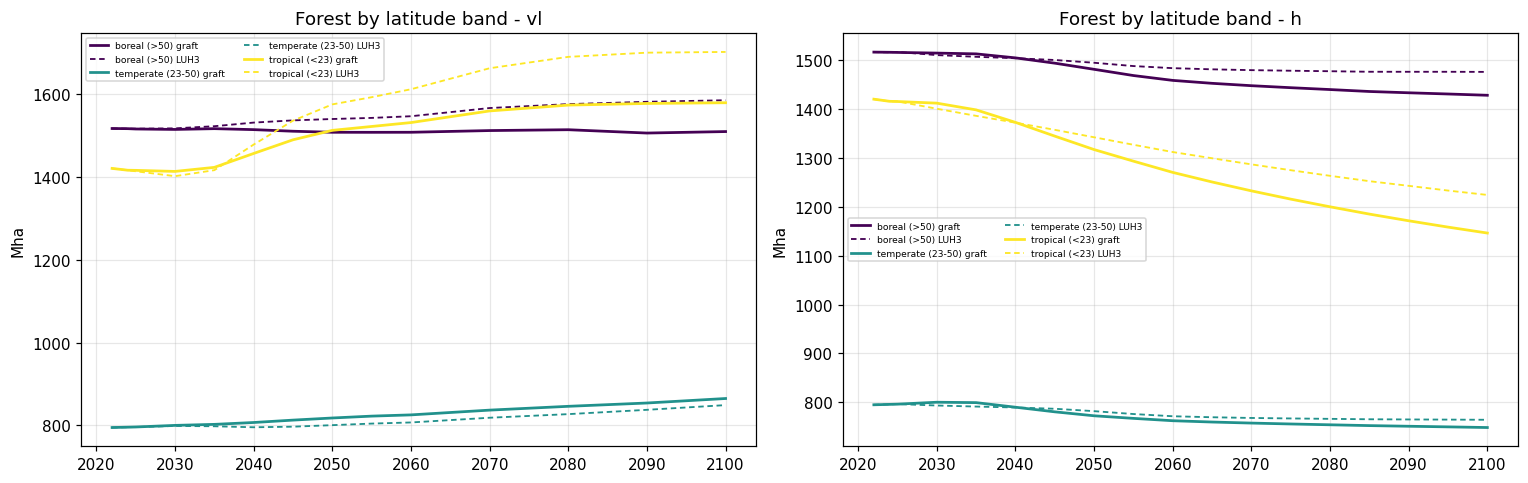

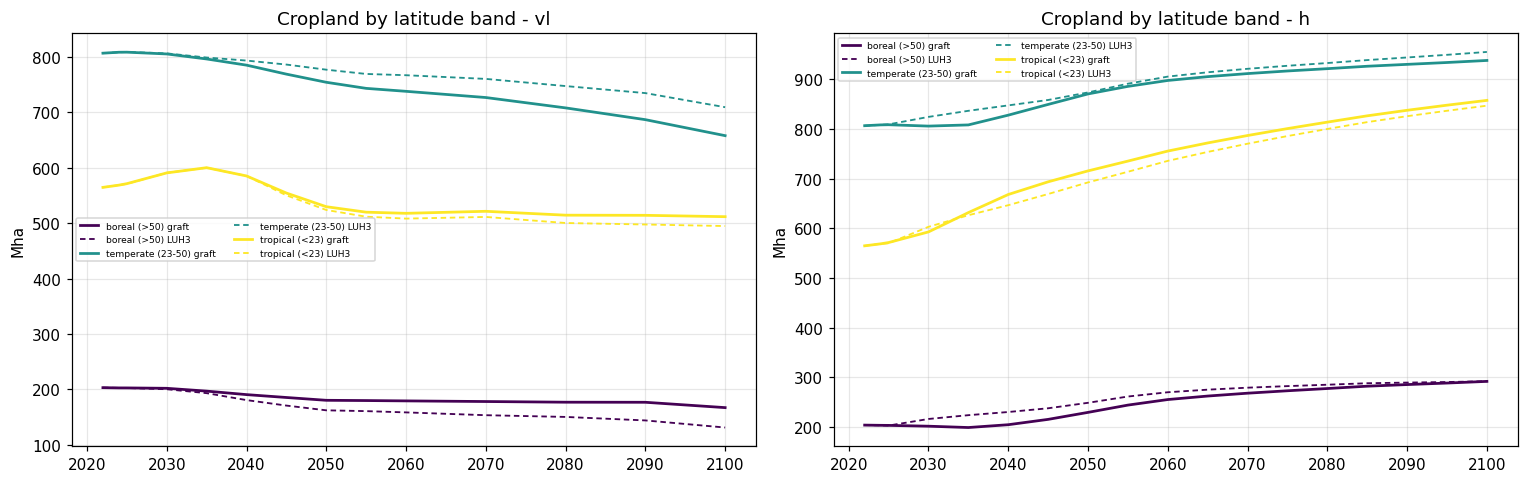

In [10]:
def band_mask(lat):
    a = np.abs(lat)
    return {"boreal (>50)": lat > 50,
            "temperate (23-50)": (a >= 23) & (a <= 50),
            "tropical (<23)": a < 23}

lat = CAREA["lat"].values
BANDS = band_mask(lat)

def band_series(path, cols):
    ds = xr.open_dataset(path, decode_times=False); yrs = years_of(ds)
    field = sum(ds[c] for c in cols if c in ds)          # fraction (time,lat,lon)
    area = (field * CAREA) / 1e4                          # Mha per cell
    out = {}
    for name, m in BANDS.items():
        out[name] = area.isel(lat=np.where(m)[0]).sum(("lat", "lon"), skipna=True).values
    ds.close()
    return pd.DataFrame(out, index=yrs)

for cols, what in ((["primf", "secdf"], "Forest"), (CROP, "Cropland")):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, key in zip(axes, ("vl", "h")):
        bo = band_series(marker_file(key, "states"), cols)
        bl = band_series(luh_file(MARKERS[key][1], "states"), cols)
        yrs = sorted(set(bo.index) & set(bl.index))
        for i, band in enumerate(BANDS):
            c = plt.get_cmap("viridis")(i / 2)
            ax.plot(yrs, bo[band].reindex(yrs), color=c, lw=1.8, label=f"{band} graft")
            ax.plot(yrs, bl[band].reindex(yrs), color=c, lw=1.2, ls=(0, (3, 2)), label=f"{band} LUH3")
        ax.set_title(f"{what} by latitude band - {key}"); ax.set_ylabel("Mha")
        ax.legend(fontsize=6, ncol=2)
    fig.tight_layout(); plt.show()


### 5b. Forest fraction maps at 2100 (vl and h): graft, LUH3, difference

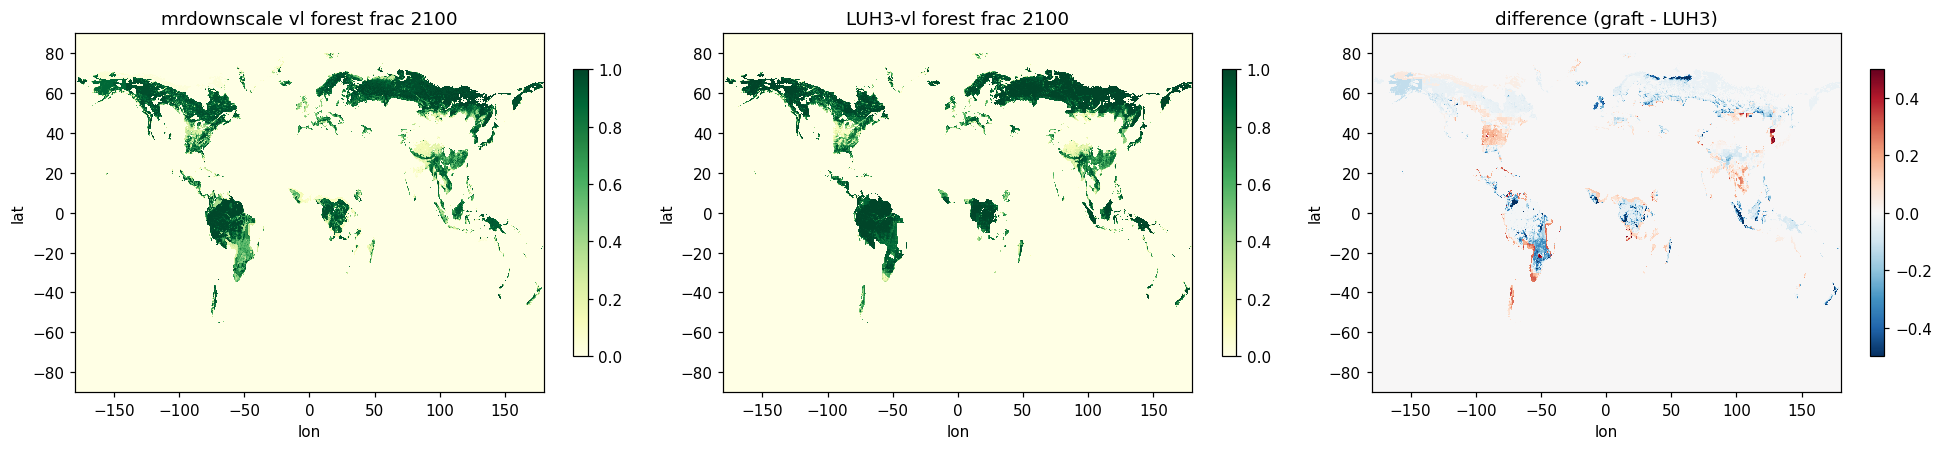

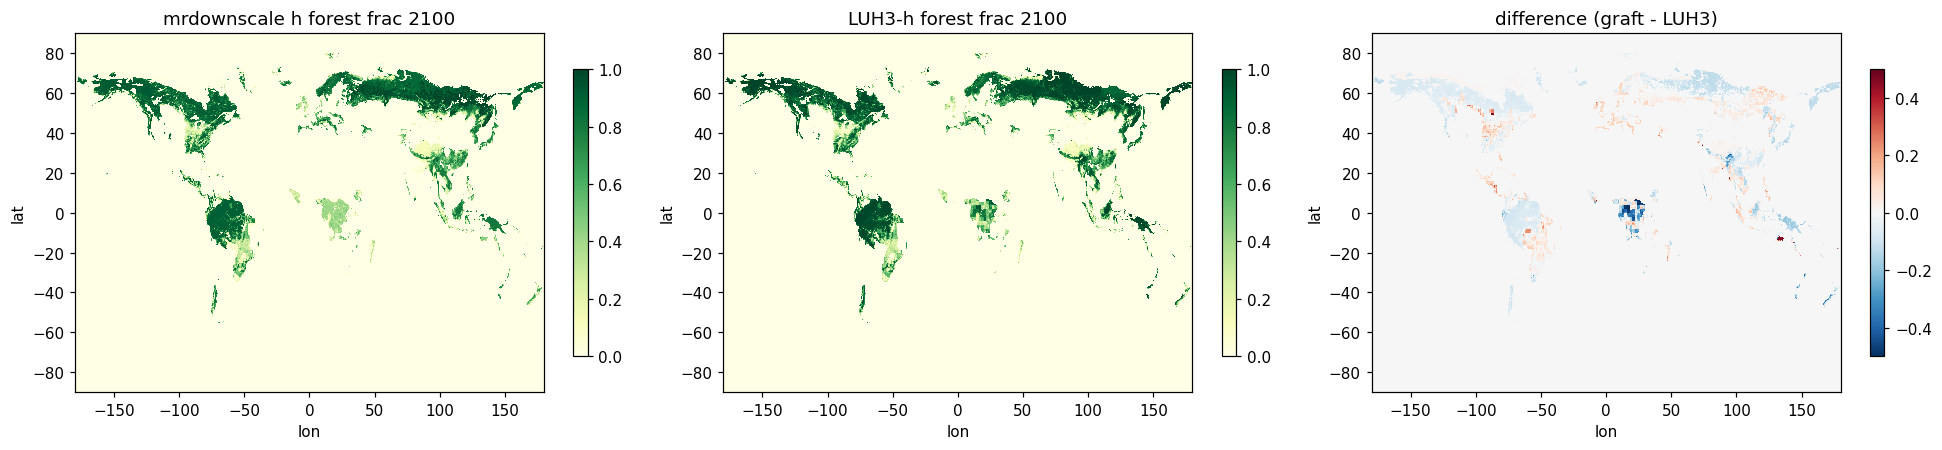

In [11]:
def forest_frac(path, year):
    ds = xr.open_dataset(path, decode_times=False); yrs = years_of(ds)
    k = int(np.argmin(np.abs(yrs - year)))
    f = (np.nan_to_num(ds["primf"].isel(time=k).values)
         + np.nan_to_num(ds["secdf"].isel(time=k).values))
    lon, lat = ds["lon"].values, ds["lat"].values
    ds.close()
    return f, lon, lat

for key in ("vl", "h"):
    of, lon, lat = forest_frac(marker_file(key, "states"), 2100)
    rf, _, _ = forest_frac(luh_file(MARKERS[key][1], "states"), 2100)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
    for ax, (data, title, cm, vlim) in zip(axes, [
            (of, f"mrdownscale {key} forest frac 2100", "YlGn", (0, 1)),
            (rf, f"LUH3-{key} forest frac 2100", "YlGn", (0, 1)),
            (of - rf, "difference (graft - LUH3)", "RdBu_r", (-0.5, 0.5))]):
        im = ax.pcolormesh(lon, lat, data, cmap=cm, vmin=vlim[0], vmax=vlim[1], shading="auto")
        ax.set_title(title); ax.set_xlabel("lon"); ax.set_ylabel("lat")
        ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout(); plt.show()


## 6. Summary

A consolidated skill table for the two markers with LUH3 references, at 2100.
The five SSP2/SSP5 markers have no published LUH3 scenario, so they are assessed
only by their global trajectories (section 1) and the history splice (section 3).

In [12]:
summary = {}
for key in ("vl", "h"):
    o, yo = states_at(marker_file(key, "states"), 2100)
    r, yr = states_at(luh_file(MARKERS[key][1], "states"), 2100)
    s = compare.score_cells(o, r, carea_np)
    summary[key] = s[["gap (%)", "cell corr"]]
    o.close(); r.close()
out = pd.concat(summary, axis=1)
print("Skill at 2100 (gap % and per-cell correlation vs LUH3)")
display(out)

print("\nSplice residuals at 2025 (forest gap vs LUH3 history, Mha):")
display(splice[["forest gap", "secdf gap", "primf gap"]])


Skill at 2100 (gap % and per-cell correlation vs LUH3)


vl                 h          
       gap (%) cell corr gap (%) cell corr
group                                     
forest   -4.40      0.98   -4.09      0.98
primf   -10.28      0.96   -0.71      0.95
secdf    -0.16      0.92   -6.53      0.94
primn     2.72      0.96   -1.29      0.88
secdn     4.44      0.93    4.27      0.90
crop      0.12      0.86   -0.25      0.94
pastr     6.87      0.89    2.46      0.93
range    -1.77      0.96    2.90      0.98
urban    14.46      0.99    1.67      1.00


Splice residuals at 2025 (forest gap vs LUH3 history, Mha):


,forest gap,secdf gap,primf gap
marker,,,
vl,-0.63,9.19,-9.82
l,-0.31,9.52,-9.82
ln,-0.19,9.64,-9.82
m,-0.31,9.51,-9.82
ml,-0.19,9.63,-9.82
h,-0.23,9.59,-9.82
hl,-0.36,9.46,-9.82
